# 第2章：Working with Text Data

**目标：** 将原始文本转化为可供 LLM 训练使用的嵌入向量

```
原始文本 → 分词(Tokenization) → Token IDs → 嵌入向量 + 位置编码 → 模型输入
```

---

## 2.1 理解词嵌入（Word Embeddings）

**核心问题：** 神经网络只能处理数字，如何让它理解文本？

**方案演进：**
1. **One-hot 编码** → 维度太高（词汇量=维度），且无法表达语义相似性
2. **Word2Vec** → 固定的语义向量，但无法处理一词多义
3. **LLM 嵌入** → 在训练过程中学习，同一个词在不同上下文中有不同表示

> 💡 **关键洞察：** LLM 的嵌入层 (`nn.Embedding`) 本质是一个**可学习的查找表**——输入 token ID，输出对应的向量。这些向量在训练过程中不断更新。

---
## 2.2 文本分词（Tokenizing Text）

分词是 NLP 的第一步：把一段文本拆分成一个个小单元（token）。

In [9]:
# 加载样本文本
with open("../data/the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

print(f"文本总长度: {len(raw_text)} 个字符")
print(f"前 200 个字符:\n{raw_text[:200]}")

文本总长度: 20479 个字符
前 200 个字符:
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married a


In [ ]:
import re

# 用正则表达式分词
# 括号 () 使分隔符也被保留在结果中
pattern = r'([,.:;?_!"()\']|--|\s)'

text_sample = "Hello, world. Is this-- a test?"
tokens = re.split(pattern, text_sample)
print(f"原始分割: {tokens[:15]}")

# 去掉空白 token
tokens = [t.strip() for t in tokens if t.strip()]
print(f"清理后:   {tokens}")

Hello!!world!!Is!this!!a!test!
原始分割: ['Hello', ',', '', ' ', 'world', '.', '', ' ', 'Is', ' ', 'this', '--', '', ' ', 'a']
清理后:   ['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']


In [10]:
# 对整篇文本分词
all_tokens = re.split(pattern, raw_text)
all_tokens = [t.strip() for t in all_tokens if t.strip()]

print(f"Token 总数: {len(all_tokens)}")
print(f"前 30 个 token: {all_tokens[:30]}")

Token 总数: 4690
前 30 个 token: ['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


### ✏️ 练习
1. 试试去掉正则中的 `--`，看 `"this-- a"` 会怎么分词 <br>
   替换后’this-- a‘ 会分词为’this--', 'a'

2. 如果把 `\s` 换成 ` `（只匹配空格），换行符会怎样？<br>
   如果把`\s` 换成 ` `（只匹配空格），换行不会进行分词，但是对于我们的text_sample，没有任何区别

In [ ]:
# 在这里做实验
# 去掉 --
pattern_test = r'([,.:;?_!"()\']|\s)'
test = re.split(pattern_test, text_sample)
print(test)

['Hello', ',', '', ' ', 'world', '.', '', ' ', 'Is', ' ', 'this--', ' ', 'a', ' ', 'test', '?', '']
{'b', 'a'}


---
## 2.3 Token → Token ID

有了 token 列表，下一步是建立 **词汇表（vocabulary）**，把每个 token 映射到一个唯一的整数 ID。

In [16]:
# 构建词汇表
all_words = sorted(set(all_tokens))
vocab_size = len(all_words)
print(f"唯一 token 数（词汇表大小）: {vocab_size}")

# 创建双向映射
vocab = {token: i for i, token in enumerate(all_words)}

# 看看词汇表的前 10 个和最后 10 个
print("\n词汇表前 10 个:")
for k, v in list(vocab.items())[:10]:
    print(f"  '{k}' → {v}")

print("\n词汇表后 10 个:")
for k, v in list(vocab.items())[-10:]:
    print(f"  '{k}' → {v}")

唯一 token 数（词汇表大小）: 1130

词汇表前 10 个:
  '!' → 0
  '"' → 1
  ''' → 2
  '(' → 3
  ')' → 4
  ',' → 5
  '--' → 6
  '.' → 7
  ':' → 8
  ';' → 9

词汇表后 10 个:
  'would' → 1120
  'wouldn' → 1121
  'year' → 1122
  'years' → 1123
  'yellow' → 1124
  'yet' → 1125
  'you' → 1126
  'younger' → 1127
  'your' → 1128
  'yourself' → 1129


In [24]:
# 实现 SimpleTokenizerV1
class SimpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {v: k for k, v in vocab.items()}

    def encode(self, text):
        """文本 → Token IDs"""
        tokens = re.split(r'([,.:;?_!"()\']|--|\s)', text)
        tokens = [t.strip() for t in tokens if t.strip()]
        return [self.str_to_int[t] for t in tokens]

    def decode(self, ids):
        """Token IDs → 文本"""
        print(self.int_to_str)
        tokens = [self.int_to_str[i] for i in ids]
        return " ".join(tokens)

In [25]:
# 测试：编码 → 解码 往返
tokenizer_v1 = SimpleTokenizerV1(vocab)

test_text = "It's the last he painted, you know."
ids = tokenizer_v1.encode(test_text)
print(f"原文:   {test_text}")
print(f"编码:   {ids}")
print(f"解码:   {tokenizer_v1.decode(ids)}")

原文:   It's the last he painted, you know.
编码:   [56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 7]
{0: '!', 1: '"', 2: "'", 3: '(', 4: ')', 5: ',', 6: '--', 7: '.', 8: ':', 9: ';', 10: '?', 11: 'A', 12: 'Ah', 13: 'Among', 14: 'And', 15: 'Are', 16: 'Arrt', 17: 'As', 18: 'At', 19: 'Be', 20: 'Begin', 21: 'Burlington', 22: 'But', 23: 'By', 24: 'Carlo', 25: 'Chicago', 26: 'Claude', 27: 'Come', 28: 'Croft', 29: 'Destroyed', 30: 'Devonshire', 31: 'Don', 32: 'Dubarry', 33: 'Emperors', 34: 'Florence', 35: 'For', 36: 'Gallery', 37: 'Gideon', 38: 'Gisburn', 39: 'Gisburns', 40: 'Grafton', 41: 'Greek', 42: 'Grindle', 43: 'Grindles', 44: 'HAD', 45: 'Had', 46: 'Hang', 47: 'Has', 48: 'He', 49: 'Her', 50: 'Hermia', 51: 'His', 52: 'How', 53: 'I', 54: 'If', 55: 'In', 56: 'It', 57: 'Jack', 58: 'Jove', 59: 'Just', 60: 'Lord', 61: 'Made', 62: 'Miss', 63: 'Money', 64: 'Monte', 65: 'Moon-dancers', 66: 'Mr', 67: 'Mrs', 68: 'My', 69: 'Never', 70: 'No', 71: 'Now', 72: 'Nutley', 73: 'Of', 74: 'Oh', 75: 'On', 76: '

### ✏️ 练习
试试编码一个词汇表中不存在的词，看会发生什么：
```python
tokenizer_v1.encode("Hello world")
```
这就是为什么我们需要特殊 token → 下一节解决这个问题。

In [26]:
# 在这里尝试编码未知词
tokenizer_v1.encode("Hello world")


KeyError: 'Hello'

---
## 2.4 添加特殊 Token

两个关键的特殊 token：
- **`<|unk|>`** — 代替所有不在词汇表中的未知词
- **`<|endoftext|>`** — 标记不同文档/文本之间的边界（GPT 预训练时会把多篇文档拼在一起）

In [27]:
# 扩展词汇表
all_words_v2 = sorted(set(all_tokens))
all_words_v2.extend(["<|endoftext|>", "<|unk|>"])
vocab_v2 = {token: i for i, token in enumerate(all_words_v2)}

print(f"V1 词汇表大小: {vocab_size}")
print(f"V2 词汇表大小: {len(vocab_v2)}")
print(f"<|endoftext|> ID: {vocab_v2['<|endoftext|>']}")
print(f"<|unk|> ID:       {vocab_v2['<|unk|>']}")

V1 词汇表大小: 1130
V2 词汇表大小: 1132
<|endoftext|> ID: 1130
<|unk|> ID:       1131


In [36]:
# 实现 SimpleTokenizerV2（处理未知词）
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {v: k for k, v in vocab.items()}

    def encode(self, text):
        tokens = re.split(r'([,.:;?_!"()\']|--|\s)', text)
        tokens = [t.strip() for t in tokens if t.strip()]
        # 关键改进：未知词用 <|unk|> 替代
        # 如果t在self.str_to_int中，则返回t，否则返回<|unk|>
        return [self.str_to_int.get(t, self.str_to_int["<|unk|>"]) for t in tokens]

    def decode(self, ids):
        tokens = [self.int_to_str.get(i, "<|unk|>") for i in ids]
        text = " ".join(tokens)
        # 改进：去掉标点前的多余空格
        text = re.sub(r'\s+([,.:;?!"()\'])', r'\1', text)
        return text

In [37]:
# 测试 V2
tokenizer_v2 = SimpleTokenizerV2(vocab_v2)

# 测试1：包含未知词
text1 = "Hello, do you like tea?"
ids1 = tokenizer_v2.encode(text1)
print(f"原文: {text1}")
print(f"编码: {ids1}")
print(f"解码: {tokenizer_v2.decode(ids1)}")
print(f"→ 'Hello' 变成了 <|unk|>，因为词汇表中只有小写的 token")
print()

# 测试2：用 <|endoftext|> 连接两段文本
text2 = "Is this a test. <|endoftext|> It is indeed."
ids2 = tokenizer_v2.encode(text2)
print(f"原文: {text2}")
print(f"编码: {ids2}")
print(f"解码: {tokenizer_v2.decode(ids2)}")

原文: Hello, do you like tea?
编码: [1131, 5, 355, 1126, 628, 975, 10]
解码: <|unk|>, do you like tea?
→ 'Hello' 变成了 <|unk|>，因为词汇表中只有小写的 token

原文: Is this a test. <|endoftext|> It is indeed.
编码: [1131, 999, 115, 1131, 7, 1130, 56, 584, 1131, 7]
解码: <|unk|> this a <|unk|>. <|endoftext|> It is <|unk|>.


### 🤔 思考

这个简单分词器的**根本问题**：
- 词汇表完全取决于训练文本，新词一律变成 `<|unk|>`
- 大小写敏感（"Hello" ≠ "hello"）
- 词汇表会随着语料增长而爆炸

→ 我们需要一个更聪明的分词方案 → **BPE**

---

## 2.5 字节对编码（Byte Pair Encoding, BPE）⭐

BPE 是 GPT 系列模型**实际使用的分词算法**。

**核心思想：**
1. 从字符级别开始
2. 反复合并最频繁出现的相邻字符对
3. 直到达到目标词汇量

```
示例："low lower lowest"
初始: [l, o, w, _, l, o, w, e, r, _, l, o, w, e, s, t]
合并 (l,o)→lo:  [lo, w, _, lo, w, e, r, _, lo, w, e, s, t]
合并 (lo,w)→low: [low, _, low, e, r, _, low, e, s, t]
合并 (low,e)→lowe: [low, _, lowe, r, _, lowe, s, t]
...
```

**优点：** 常见词保持完整，罕见词自动拆分为子词，永远不会有 `<|unk|>`！

In [38]:
# tiktoken 是 OpenAI 开源的 BPE 分词库，是 GPT 系列模型（GPT-2、GPT-3、GPT-4）实际使用的分词器。
import tiktoken

# GPT-2 的 BPE 分词器
tokenizer = tiktoken.get_encoding("gpt2")

text = "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})

print(f"原文: {text}")
print(f"Token IDs: {integers}")
print(f"Token 数量: {len(integers)}")
print(f"解码: {tokenizer.decode(integers)}")
print(f"\nGPT-2 词汇表大小: {tokenizer.n_vocab}")

原文: Hello, do you like tea? <|endoftext|> In the sunlit terraces
Token IDs: [15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114]
Token 数量: 15
解码: Hello, do you like tea? <|endoftext|> In the sunlit terraces

GPT-2 词汇表大小: 50257


In [39]:
# 🔍 观察 BPE 如何拆分不同的词
words = ["Akwirw", "unforgettable", "ChatGPT", "tokenization", "Hello", "lowest"]

print("BPE 子词拆分结果：")
print("-" * 50)
for word in words:
    ids = tokenizer.encode(word)
    sub_tokens = [tokenizer.decode([i]) for i in ids]
    print(f"  {word:20s} → {sub_tokens}")

BPE 子词拆分结果：
--------------------------------------------------
  Akwirw               → ['Ak', 'w', 'ir', 'w']
  unforgettable        → ['un', 'for', 'gettable']
  ChatGPT              → ['Chat', 'G', 'PT']
  tokenization         → ['token', 'ization']
  Hello                → ['Hello']
  lowest               → ['low', 'est']


In [40]:
# 🔍 BPE 处理中文
chinese_texts = ["你好世界", "大语言模型", "注意力机制"]

print("中文 BPE 分词：")
print("-" * 50)
for text in chinese_texts:
    ids = tokenizer.encode(text)
    sub_tokens = [tokenizer.decode([i]) for i in ids]
    print(f"  {text:10s} → {len(ids)} tokens → {sub_tokens}")

print("\n💡 中文每个字通常需要 2-3 个 BPE token，因为 GPT-2 的词汇表以英文为主")

中文 BPE 分词：
--------------------------------------------------
  你好世界       → 8 tokens → ['�', '�', '�', '�', '�', '�', '�', '�']
  大语言模型      → 12 tokens → ['大', '�', '�', '�', '�', '�', '�', '�', '�', '�', '�', '�']
  注意力机制      → 10 tokens → ['�', '�', '�', '�', '�', '�', '�', '�', '�', '�']

💡 中文每个字通常需要 2-3 个 BPE token，因为 GPT-2 的词汇表以英文为主


### ✏️ 练习
对比 GPT-2 (`gpt2`) 和 GPT-4 (`cl100k_base`) 的分词差异：

In [45]:
tokenizer_gpt2 = tiktoken.get_encoding("gpt2")
tokenizer_gpt4 = tiktoken.get_encoding("cl100k_base")

test = "Hello, how are you doing, today? 你好世界"
ids_v2 = tokenizer_gpt2.encode(test)
ids_v4 = tokenizer_gpt4.encode(test)

print(f"原文: {test}")
print(f"\nGPT-2  ({tokenizer_gpt2.n_vocab:,} 词汇): {len(ids_v2)} tokens")
print(ids_v2)
print(f"  → {[tokenizer_gpt2.decode([i]) for i in ids_v2]}")
print(f"\nGPT-4  ({tokenizer_gpt4.n_vocab:,} 词汇): {len(ids_v4)} tokens")
print(ids_v4)
print(f"  → {[tokenizer_gpt4.decode([i]) for i in ids_v4]}")
print(f"\n💡 更大的词汇表 → 更少的 token → 更高效，但嵌入层参数更多")

原文: Hello, how are you doing, today? 你好世界

GPT-2  (50,257 词汇): 18 tokens
[15496, 11, 703, 389, 345, 1804, 11, 1909, 30, 220, 19526, 254, 25001, 121, 10310, 244, 45911, 234]
  → ['Hello', ',', ' how', ' are', ' you', ' doing', ',', ' today', '?', ' ', '�', '�', '�', '�', '�', '�', '�', '�']

GPT-4  (100,277 词汇): 15 tokens
[9906, 11, 1268, 527, 499, 3815, 11, 3432, 30, 220, 57668, 53901, 3574, 244, 98220]
  → ['Hello', ',', ' how', ' are', ' you', ' doing', ',', ' today', '?', ' ', '你', '好', '�', '�', '界']

💡 更大的词汇表 → 更少的 token → 更高效，但嵌入层参数更多


---
## 2.6 滑动窗口采样（Data Sampling with Sliding Window）⭐⭐

LLM 训练的本质是 **next-token prediction**：给定前面的 token，预测下一个 token。

```
文本: [The, cat, sat, on, the, mat]
context_size = 4

样本1: input=[The, cat, sat, on]   → target=[cat, sat, on, the]
样本2: input=[cat, sat, on, the]   → target=[sat, on, the, mat]

注意：target 就是 input 右移一位！
```

In [47]:
# 先直观理解：用一小段文本看 input/target 对
enc_text = tokenizer.encode(raw_text)
print(f"全文 token 数: {len(enc_text)}")

# 取前 20 个 token
sample = enc_text[:20]
context_size = 4

print(f"\n前 20 个 token: {sample}")
print(f"解码: '{tokenizer.decode(sample)}'")
print(f"\n滑动窗口生成的 input → target 对 (context_size={context_size}):")
print("-" * 60)

for i in range(0, len(sample) - context_size, 1):
    x = sample[i:i + context_size]
    y = sample[i + 1:i + context_size + 1]
    x_text = tokenizer.decode(x)
    y_text = tokenizer.decode(y)
    if i < 5:  # 只打印前 5 个
        print(f"  input:  {str(x):30s} → '{x_text}'")
        print(f"  target: {str(y):30s} → '{y_text}'")
        print()

全文 token 数: 5145

前 20 个 token: [40, 367, 2885, 1464, 1807, 3619, 402, 271, 10899, 2138, 257, 7026, 15632, 438, 2016, 257, 922, 5891, 1576, 438]
解码: 'I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--'

滑动窗口生成的 input → target 对 (context_size=4):
------------------------------------------------------------
  input:  [40, 367, 2885, 1464]          → 'I HAD always'
  target: [367, 2885, 1464, 1807]        → ' HAD always thought'

  input:  [367, 2885, 1464, 1807]        → ' HAD always thought'
  target: [2885, 1464, 1807, 3619]       → 'AD always thought Jack'

  input:  [2885, 1464, 1807, 3619]       → 'AD always thought Jack'
  target: [1464, 1807, 3619, 402]        → ' always thought Jack G'

  input:  [1464, 1807, 3619, 402]        → ' always thought Jack G'
  target: [1807, 3619, 402, 271]         → ' thought Jack Gis'

  input:  [1807, 3619, 402, 271]         → ' thought Jack Gis'
  target: [3619, 402, 271, 10899]        → ' Jack Gisburn'



In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    """GPT 训练数据集 — 滑动窗口生成 input/target 对"""

    def __init__(self, txt, tokenizer, max_length, stride):
        """
        Args:
            txt:        原始文本字符串，用于生成训练样本
            tokenizer:  分词器（如 tiktoken），负责将文本编码为 token ID
            max_length: 每个样本的上下文窗口长度（即模型一次看多少个 token）
            stride:     滑动窗口步长（stride < max_length 时样本之间有重叠）
        """
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1:i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128,
                         shuffle=True, drop_last=True, num_workers=0):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)
    return DataLoader(
        dataset, batch_size=batch_size,
        shuffle=shuffle, drop_last=drop_last, num_workers=num_workers,
    )


print("✅ GPTDatasetV1 和 create_dataloader_v1 已定义")

✅ GPTDatasetV1 和 create_dataloader_v1 已定义


In [66]:
# 实验1：小窗口，直观理解
print("实验1：max_length=4, stride=4（无重叠）")
print("=" * 50)

dl = create_dataloader_v1(raw_text, batch_size=1, max_length=4, stride=4, shuffle=False)

for i, (inputs, targets) in enumerate(dl):
    if i >= 3:
        break
    print(f"样本 {i}:")
    print(f"  Input:  {inputs[0].tolist()} → '{tokenizer.decode(inputs[0].tolist())}'")
    print(f"  Target: {targets[0].tolist()} → '{tokenizer.decode(targets[0].tolist())}'")
    print()

实验1：max_length=4, stride=4（无重叠）
样本 0:
  Input:  [40, 367, 2885, 1464] → 'I HAD always'
  Target: [367, 2885, 1464, 1807] → ' HAD always thought'

样本 1:
  Input:  [1807, 3619, 402, 271] → ' thought Jack Gis'
  Target: [3619, 402, 271, 10899] → ' Jack Gisburn'

样本 2:
  Input:  [10899, 2138, 257, 7026] → 'burn rather a cheap'
  Target: [2138, 257, 7026, 15632] → ' rather a cheap genius'



In [63]:
# 实验2：stride 对样本数量的影响
for stride in [1, 2, 4]:
    dl = create_dataloader_v1(raw_text, batch_size=1, max_length=4, stride=stride, shuffle=False)
    print(f"stride={stride} → 样本数: {len(dl.dataset):>5}  "
          f"({'高重叠' if stride < 4 else '无重叠'})")

print("\n💡 stride 越小 → 重叠越多 → 样本越多，但数据冗余也越高")

stride=1 → 样本数:  5141  (高重叠)
stride=2 → 样本数:  2571  (高重叠)
stride=4 → 样本数:  1286  (无重叠)

💡 stride 越小 → 重叠越多 → 样本越多，但数据冗余也越高


In [ ]:
# 实验3：实际训练常用的设置
print("实际训练设置：batch_size=8, max_length=256")
print("=" * 50)

dataloader = create_dataloader_v1(
    raw_text, batch_size=8, max_length=256, stride=256, shuffle=False
)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)

print(f"Input batch shape:  {inputs.shape}")   # (8, 256)
print(f"Target batch shape: {targets.shape}")   # (8, 256)
print(f"总 batch 数: {len(dataloader)}")

实际训练设置：batch_size=8, max_length=256
Input batch shape:  torch.Size([8, 256])
Target batch shape: torch.Size([8, 256])
总 batch 数: 2


### ✏️ 练习
1. `max_length` 和 `stride` 分别控制什么？`stride < max_length` 时会怎样？<br>
    max_length 控制每次取的样本的最大长度（如果字符串数量不够的时候，可能少于 max_length）， `stride < max_length`时，会出现不同相邻样本之间取词有重叠的情况
2. `drop_last=True` 的作用是什么？（提示：最后一个 batch 可能不满）<br>
    在最后一个 batch 不满的时候丢弃这个batch
3. 如果文本只有 100 个 token，但 `max_length=256`，会发生什么？<br>
  会导致样本的数量不足，不会生成任何样本

In [ ]:
# 在这里做实验

---
## 2.7 Token 嵌入 + 位置编码 ⭐⭐

最后一步：把 Token IDs 转化为连续的向量表示，这才是 Transformer 能处理的格式。

**两个嵌入层：**
- **Token Embedding**: Token ID → 语义向量（这个词是什么意思）
- **Positional Embedding**: 位置 → 位置向量（这个词在哪个位置）

**最终输入 = Token Embedding + Positional Embedding**

In [67]:
# 先理解 nn.Embedding 的本质：可学习的查找表
toy_emb = torch.nn.Embedding(6, 3)  # 6 个词，每个 3 维向量
print(f"权重矩阵 shape: {toy_emb.weight.shape}")
print(f"权重矩阵:\n{toy_emb.weight.data}")

# 输入 ID 2 → 取出第 2 行
input_ids = torch.tensor([2, 0, 5])
output = toy_emb(input_ids)
print(f"\n输入 IDs: {input_ids.tolist()}")
print(f"输出:\n{output}")
print(f"\noutput[0] == weight[2]? {torch.allclose(output[0], toy_emb.weight[2])}")

权重矩阵 shape: torch.Size([6, 3])
权重矩阵:
tensor([[ 0.1021,  1.8480,  0.9659],
        [ 1.8615,  0.6244,  0.0593],
        [ 0.4773,  0.5370,  0.7451],
        [ 2.1996,  1.1792,  0.6968],
        [-0.9059,  0.5382,  0.1044],
        [-0.1662,  0.7738, -0.0779]])

输入 IDs: [2, 0, 5]
输出:
tensor([[ 0.4773,  0.5370,  0.7451],
        [ 0.1021,  1.8480,  0.9659],
        [-0.1662,  0.7738, -0.0779]], grad_fn=<EmbeddingBackward0>)

output[0] == weight[2]? True


In [69]:
# GPT-2 参数设置
vocab_size = 50257       # 词汇表大小
output_dim = 256         # 嵌入维度（GPT-2 实际用 768，这里用 256 方便学习）
context_length = 1024    # 最大上下文长度

# 创建嵌入层
token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)

print(f"Token Embedding 参数量: {vocab_size:,} × {output_dim} = {vocab_size * output_dim:,}")
print(f"Pos   Embedding 参数量: {context_length:,} × {output_dim} = {context_length * output_dim:,}")

Token Embedding 参数量: 50,257 × 256 = 12,865,792
Pos   Embedding 参数量: 1,024 × 256 = 262,144


In [ ]:
# 模拟一个输入 batch
text = "Every effort moves you"
ids = tokenizer.encode(text)
batch = torch.tensor([ids])  # 加 batch 维度 → shape: (1, 4)

print(f"文本: '{text}'")
print(f"Token IDs: {ids}")
print(f"Batch shape: {batch.shape}")

# Step 1: Token Embedding
token_emb = token_embedding_layer(batch)
print(f"\nToken Embedding shape: {token_emb.shape}")  # (1, 4, 256)

# Step 2: Positional Embedding
seq_len = batch.shape[1]
positions = torch.arange(seq_len)  # [0, 1, 2, 3]
pos_emb = pos_embedding_layer(positions)
print(f"Position Embedding shape: {pos_emb.shape}")   # (4, 256)

# Step 3: 相加（广播）
input_embeddings = token_emb + pos_emb  # (1,4,256) + (4,256) → (1,4,256)
print(f"\n最终输入 shape: {input_embeddings.shape}")
print(f"\n🎉 这就是送入 Transformer 第一层的输入！")

Matplotlib is building the font cache; this may take a moment.
/var/folders/7_/_wb4_jsn4775ss_mp7tft5pr0000gn/T/ipykernel_50959/2980069681.py:20: UserWarning: Glyph 23884 (\N{CJK UNIFIED IDEOGRAPH-5D4C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7_/_wb4_jsn4775ss_mp7tft5pr0000gn/T/ipykernel_50959/2980069681.py:20: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7_/_wb4_jsn4775ss_mp7tft5pr0000gn/T/ipykernel_50959/2980069681.py:20: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7_/_wb4_jsn4775ss_mp7tft5pr0000gn/T/ipykernel_50959/2980069681.py:20: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/7_/_wb4_jsn4775ss_mp7tft5pr0000gn/T/ipykernel_50959/2980069681.py:20: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from

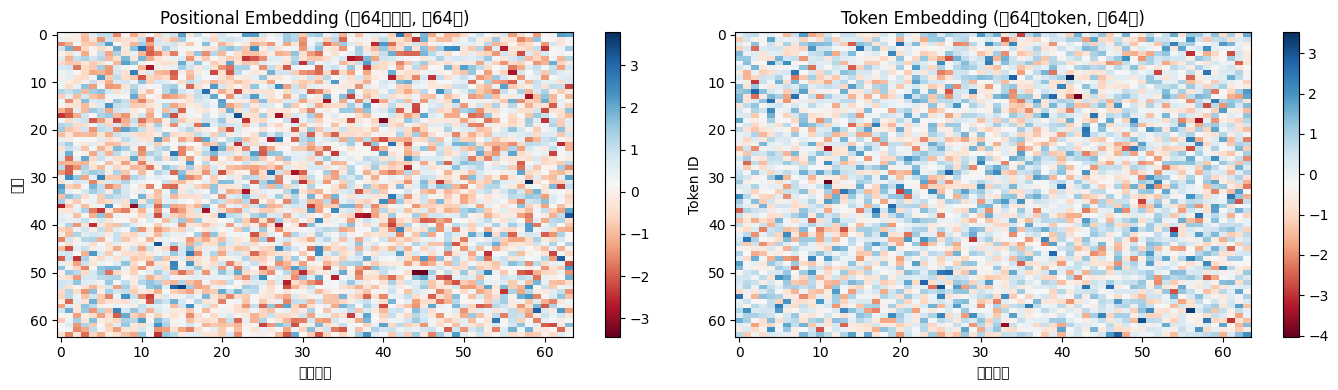

💡 这是随机初始化的权重，训练后会形成有意义的 pattern


In [70]:
# 可视化：位置编码的权重矩阵（初始化状态）
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 位置嵌入
im1 = axes[0].imshow(pos_embedding_layer.weight.data[:64, :64].numpy(), cmap='RdBu', aspect='auto')
axes[0].set_title('Positional Embedding (前64个位置, 前64维)')
axes[0].set_xlabel('嵌入维度')
axes[0].set_ylabel('位置')
plt.colorbar(im1, ax=axes[0])

# Token 嵌入（取前 64 个 token）
im2 = axes[1].imshow(token_embedding_layer.weight.data[:64, :64].numpy(), cmap='RdBu', aspect='auto')
axes[1].set_title('Token Embedding (前64个token, 前64维)')
axes[1].set_xlabel('嵌入维度')
axes[1].set_ylabel('Token ID')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()
print("💡 这是随机初始化的权重，训练后会形成有意义的 pattern")

### ✏️ 练习
1. 为什么 Token Embedding 和 Positional Embedding 要**相加**而不是拼接？
   > 提示：拼接会让维度翻倍 (256+256=512)，后续层都要跟着改
2. `nn.Embedding(50257, 768)` 有多少可学习参数？
3. GPT-2 用可学习的位置编码，原始 Transformer 用固定的正弦位置编码，各有什么优缺点？

In [ ]:
# 在这里做实验


---
## 🔗 完整 Pipeline 串联

把本章所有步骤串起来，形成从原始文本到模型输入的完整流程。

In [ ]:
# ===== 完整 Pipeline =====
VOCAB_SIZE = 50257
OUTPUT_DIM = 256
CONTEXT_LENGTH = 256
BATCH_SIZE = 8

# 1. 加载文本
with open("../data/the-verdict.txt", "r") as f:
    raw_text = f.read()
total_tokens = len(tokenizer.encode(raw_text))

# 2. DataLoader
dataloader = create_dataloader_v1(
    raw_text, batch_size=BATCH_SIZE,
    max_length=CONTEXT_LENGTH, stride=CONTEXT_LENGTH, shuffle=False,
)

# 3. 嵌入层
token_emb_layer = torch.nn.Embedding(VOCAB_SIZE, OUTPUT_DIM)
pos_emb_layer = torch.nn.Embedding(CONTEXT_LENGTH, OUTPUT_DIM)

# 4. 处理一个 batch
inputs, targets = next(iter(dataloader))
token_emb = token_emb_layer(inputs)
pos_emb = pos_emb_layer(torch.arange(CONTEXT_LENGTH))
input_embeddings = token_emb + pos_emb

# 5. 总结
print("完整 Pipeline:")
print("=" * 50)
print(f"  原始文本        → {len(raw_text):,} chars")
print(f"  ↓ tiktoken BPE")
print(f"  Token IDs       → {total_tokens:,} tokens")
print(f"  ↓ 滑动窗口 (len={CONTEXT_LENGTH}, stride={CONTEXT_LENGTH})")
print(f"  训练样本        → {len(dataloader.dataset)} pairs")
print(f"  ↓ DataLoader (batch={BATCH_SIZE})")
print(f"  Input Batch     → {inputs.shape}")
print(f"  ↓ Token Emb + Pos Emb")
print(f"  模型输入        → {input_embeddings.shape}")
print(f"  ↓")
print(f"  送入 Transformer... (第3章继续!)")

---
## 📝 本章核心 Checklist

学完后确认你能回答：

- [ ] 为什么需要 tokenization？为什么不直接用字符级别？
- [ ] BPE 算法的核心思想是什么？它如何处理未见过的词？
- [ ] `<|endoftext|>` token 的作用是什么？
- [ ] 滑动窗口的 `max_length` 和 `stride` 各自控制什么？
- [ ] Token Embedding 和 Positional Embedding 为什么要相加而不是拼接？
- [ ] `nn.Embedding(50257, 768)` 有多少可学习参数？
- [ ] 输入 shape `(batch, seq_len)` 经过嵌入后输出 shape 是什么？

全部能回答 → 进入第 3 章：注意力机制！🚀